In [1]:
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from datetime import datetime, timedelta

# Locate premier_league/ regardless of where Jupyter was launched
_here = Path.cwd()
if not (_here / 'outputs.ipynb').exists():
    for _c in [_here / 'premier_league',
               _here / 'non_penalty_bayes' / 'premier_league',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
NP_BAYES_DIR = str(NOTEBOOK_DIR.parent)
sys.path.insert(0, NP_BAYES_DIR)

REPO_ROOT = str(NOTEBOOK_DIR.parents[4])
sys.path.insert(0, os.path.join(REPO_ROOT, 'viz'))

from src.data_utils import load_and_process_data, load_football_data, create_weighted_scoreline_data, prepare_model_data
from src.model import build_and_sample_model
from src.simulation import (run_multiple_seasons, load_actual_results,
                             get_actual_standings, form_net_rating,
                             get_last_result, get_form_string, rank_arrow)
from pl_combined_table import render_combined_table
from pl_html_export import render_html_export
from pl_evo_chart import render_evo_chart
from pl_scatter import render_scatter
from logos import TEAM_LOGOS as team_logos

LEAGUE  = 'Premier_League'
SEASON  = '2025-2026'

DB_PATH = os.path.join(REPO_ROOT, 'infra', 'data', 'db', 'fotmob.db')

# Sampling
N_SAMPLES           = 20000
N_TUNE              = 10000
N_SAMPLES_EVOLUTION = 2000
N_TUNE_EVOLUTION    = 1000

# Blend weights
DECAY_RATE   = 0.0018
GOALS_WEIGHT = 0.25
XG_WEIGHT    = 0.50
PSXG_WEIGHT  = 0.15
EPV_WEIGHT   = 0.10

BASELINE_HOME_PENS = 0.157 * 0.78
BASELINE_AWAY_PENS = 0.101 * 0.78

# ── Form window config (update each week) ────────────────────────────────────
FORM_END      = '2026-04-06'
FORM_START    = '2025-11-24'
FORM_PREV_END = (datetime.strptime(FORM_END, '%Y-%m-%d') - timedelta(weeks=1)).strftime('%Y-%m-%d')


print(f'CWD:          {NOTEBOOK_DIR}')
print(f'DB:           {DB_PATH}')
print(f'FORM_END:     {FORM_END}')
print(f'FORM_PREV_END:{FORM_PREV_END}')

CWD:          /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league
DB:           /Users/admin/dev/algobetting/infra/data/db/fotmob.db
FORM_END:     2026-04-06
FORM_PREV_END:2026-03-30


## Current ratings — full season

In [2]:
df, team_mapping, n_teams = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON,
    decay_rate=DECAY_RATE, 
    goals_weight=GOALS_WEIGHT,
    xg_weight=XG_WEIGHT, 
    psxg_weight=PSXG_WEIGHT, 
    epv_weight=EPV_WEIGHT,

    gc_goals_weight=0,
    gc_xg_weight=0,
    gc_psxg_weight=0,
    gc_epv_weight=0,
)
team_names = list(team_mapping.keys())
print(f'{n_teams} teams, {df["match_id"].nunique()} matches')

20 teams, 309 matches


In [3]:
from manual_priors import MANUAL_ATT_PRIORS, MANUAL_DEF_PRIORS

_, trace = build_and_sample_model(
    df, n_teams, trace=N_SAMPLES, tune=N_TUNE,
    team_mapping=team_mapping,
    manual_att_priors=MANUAL_ATT_PRIORS,
    manual_def_priors=MANUAL_DEF_PRIORS,
)
print('Done.')

Done.


In [4]:
posterior = trace.posterior
att  = posterior['att_str'].values.reshape(-1, n_teams)
defn = posterior['def_str'].values.reshape(-1, n_teams)
hadv = posterior['home_adv'].values.reshape(-1)
base = posterior['baseline'].values.reshape(-1)

ratings = pd.DataFrame({
    'team':     team_names,
    'att_mean': att.mean(axis=0).round(3),
    'att_sd':   att.std(axis=0).round(3),
    'att_lo':   np.percentile(att, 5,  axis=0).round(3),
    'att_hi':   np.percentile(att, 95, axis=0).round(3),
    'def_mean': defn.mean(axis=0).round(3),
    'def_sd':   defn.std(axis=0).round(3),
    'def_lo':   np.percentile(defn, 5,  axis=0).round(3),
    'def_hi':   np.percentile(defn, 95, axis=0).round(3),
})
ratings['net'] = (ratings['att_mean'] - ratings['def_mean']).round(3)
ratings = ratings.sort_values('net', ascending=False).reset_index(drop=True)
ratings

,team,att_mean,att_sd,att_lo,att_hi,def_mean,def_sd,def_lo,def_hi,net
0,Arsenal,0.261,0.140,0.026,0.489,-0.494,0.190,-0.824,-0.193,0.755
1,Man City,0.292,0.148,0.047,0.528,-0.168,0.169,-0.451,0.105,0.460
2,Liverpool,0.245,0.143,0.010,0.471,-0.101,0.164,-0.369,0.155,0.346
3,Chelsea,0.242,0.146,0.000,0.476,-0.004,0.165,-0.286,0.265,0.246
4,Man United,0.181,0.147,-0.066,0.414,-0.035,0.163,-0.311,0.222,0.216
5,Brighton,0.057,0.154,-0.195,0.306,-0.087,0.168,-0.368,0.181,0.144
6,Brentford,0.078,0.154,-0.179,0.326,-0.054,0.160,-0.324,0.203,0.132
7,Newcastle,0.078,0.155,-0.190,0.332,-0.020,0.162,-0.290,0.235,0.098
8,Aston Villa,0.037,0.156,-0.229,0.294,0.013,0.159,-0.246,0.264,0.024
9,Crystal Palace,-0.049,0.167,-0.333,0.212,-0.039,0.166,-0.312,0.228,-0.010


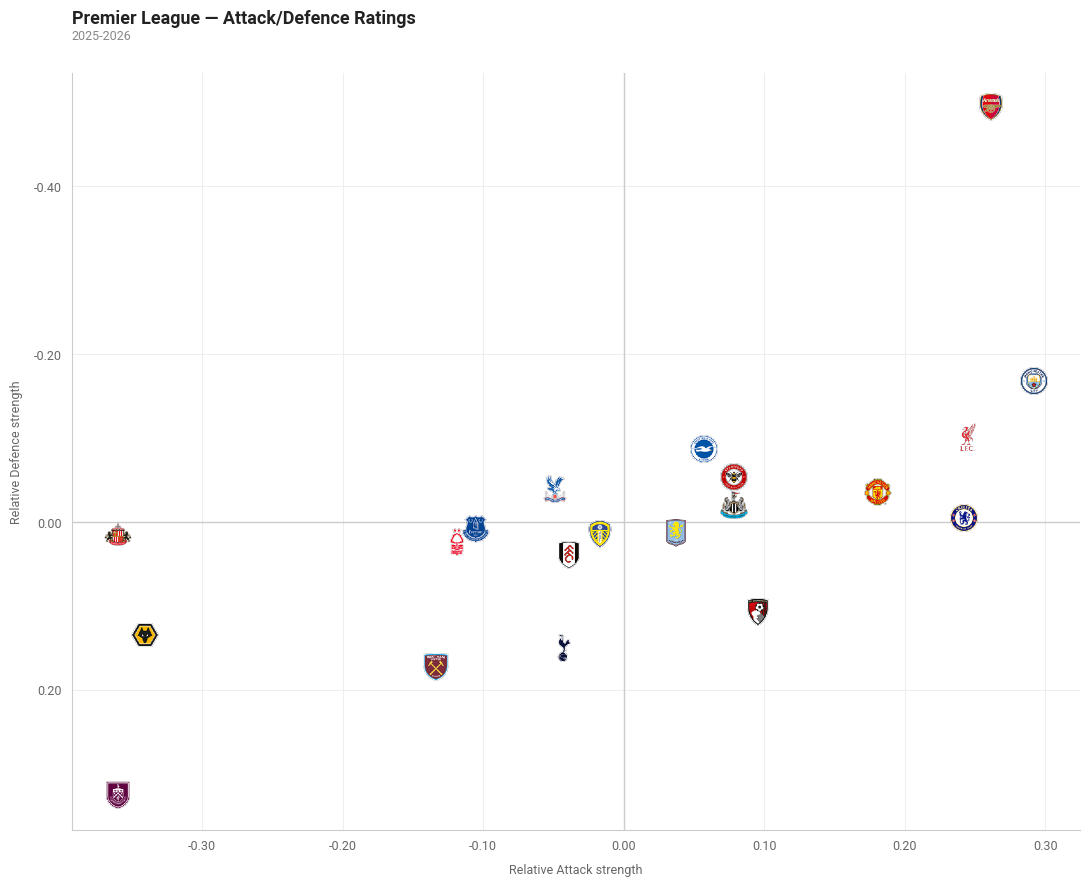

In [5]:
fig = render_scatter(ratings, season=SEASON, league='Premier League',
    save_path=os.path.join(str(NOTEBOOK_DIR), 'outputs', 'rating_scatter.png'))
plt.show()

## Season Projections

In [6]:
# ── ratings_df: Bayesian avg-vs-all-opponents (Jensen's corrected) ────────────
baseline_samples  = trace.posterior["baseline"].values.flatten()
home_adv_samples  = trace.posterior["home_adv"].values.flatten()
att_samples_all   = trace.posterior["att_str"].values.reshape(-1, n_teams)
def_samples_all   = trace.posterior["def_str"].values.reshape(-1, n_teams)
all_teams_list    = list(team_mapping.keys())

team_stats = {t: {"goals_for": 0, "goals_against": 0, "matches": 0} for t in all_teams_list}

for home_team in all_teams_list:
    hi = team_mapping[home_team]
    for away_team in all_teams_list:
        if home_team == away_team:
            continue
        ai = team_mapping[away_team]
        home_lam = np.exp(baseline_samples + home_adv_samples
                          + att_samples_all[:, hi] + def_samples_all[:, ai])
        away_lam = np.exp(baseline_samples + att_samples_all[:, ai] + def_samples_all[:, hi])

        hg = home_lam.mean() + BASELINE_HOME_PENS
        ag = away_lam.mean() + BASELINE_AWAY_PENS

        team_stats[home_team]["goals_for"]     += hg
        team_stats[home_team]["goals_against"] += ag
        team_stats[home_team]["matches"]       += 1
        team_stats[away_team]["goals_for"]     += ag
        team_stats[away_team]["goals_against"] += hg
        team_stats[away_team]["matches"]       += 1

ratings_df = pd.DataFrame([{
    "team":          t,
    "goals_for":     team_stats[t]["goals_for"]     / team_stats[t]["matches"],
    "goals_against": team_stats[t]["goals_against"] / team_stats[t]["matches"],
    "goal_diff":     (team_stats[t]["goals_for"] - team_stats[t]["goals_against"]) / team_stats[t]["matches"],
    "total_xg":      (team_stats[t]["goals_for"] + team_stats[t]["goals_against"]) / team_stats[t]["matches"],
} for t in all_teams_list]).sort_values("goal_diff", ascending=False).reset_index(drop=True)

print(ratings_df.to_string(index=False))

print('Totals')
print(f'Home goals: {ratings_df['goals_for'].sum():.2f}')
print(f'Away goals: {ratings_df['goals_against'].sum():.2f}')

          team  goals_for  goals_against  goal_diff  total_xg
       Arsenal   1.729392       0.851130   0.878261  2.580522
      Man City   1.762131       1.134448   0.627683  2.896579
     Liverpool   1.679677       1.208563   0.471115  2.888240
       Chelsea   1.668152       1.321815   0.346337  2.989968
    Man United   1.578336       1.288067   0.290269  2.866403
      Brighton   1.410002       1.237667   0.172335  2.647668
     Brentford   1.436270       1.272691   0.163579  2.708961
     Newcastle   1.433980       1.313668   0.120312  2.747647
   Aston Villa   1.378431       1.356078   0.022354  2.734509
Crystal Palace   1.278946       1.298721  -0.019776  2.577667
   Bournemouth   1.446528       1.473796  -0.027269  2.920324
         Leeds   1.314776       1.362526  -0.047750  2.677301
        Fulham   1.284693       1.394361  -0.109668  2.679054
       Everton   1.210429       1.357601  -0.147172  2.568030
  Nottm Forest   1.195561       1.380131  -0.184570  2.575692
     Tot

In [7]:
# ── Load actual results + run 10k simulations ─────────────────────────────────
df_actual = load_actual_results(DB_PATH, LEAGUE, SEASON)
print(f'Actual matches: {len(df_actual)}')

N_SIMS = 10_000
avg_table, position_freq = run_multiple_seasons(
    N_SIMS, trace, team_mapping, df_actual
)
avg_table

Actual matches: 309
Pre-computing xG for 380 fixtures...
  Played: 309   To simulate: 71
Running 10,000 simulations...
  2,000 / 10,000
  4,000 / 10,000
  6,000 / 10,000
  8,000 / 10,000


,team,avg_points,pts_low,pts_high,avg_wins,avg_draws,avg_losses,avg_goals_for,avg_goals_against,avg_xg_for,avg_xg_against,avg_position,title_pct,top5_pct,top8_pct,relegation_pct,avg_goal_difference,avg_xg_difference
1,Arsenal,84.1459,80.092802,88.198998,25.1958,8.5585,4.2457,73.8104,27.9171,65.716889,32.342958,1.0410,95.9,100.0,100.0,0.0,45.8933,33.373931
2,Man City,74.9308,70.291367,79.570233,22.0212,8.8672,7.1116,73.8195,37.3753,66.960971,43.109016,2.0047,4.1,100.0,100.0,0.0,36.4442,23.851955
3,Man United,65.7825,61.366186,70.198814,18.0194,11.7243,8.2563,66.7803,52.0912,59.976762,48.946550,3.6353,0.0,94.0,99.9,0.0,14.6891,11.030212
4,Aston Villa,64.0890,59.708467,68.469533,18.7838,7.7376,11.4786,51.8442,46.2128,52.380394,51.530952,4.2563,0.0,86.8,99.5,0.0,5.6314,0.849442
5,Liverpool,60.5785,56.139457,65.017543,17.3004,8.6773,12.0223,61.6260,50.7326,63.827739,45.925379,5.4810,0.0,57.1,94.2,0.0,10.8934,17.902361
6,Chelsea,58.8673,54.492116,63.242484,16.0764,10.6381,11.2855,64.4794,47.6475,63.389785,50.228988,6.1245,0.0,39.0,90.1,0.0,16.8319,13.160798
7,Brentford,56.0793,51.751345,60.407255,15.7958,8.6919,13.5123,55.9496,51.4105,54.578262,48.362274,7.9436,0.0,10.8,64.1,0.0,4.5391,6.215988
8,Everton,54.7357,50.437178,59.034222,15.3005,8.8342,13.8653,45.3132,44.5746,45.996297,51.588836,8.9305,0.0,5.3,45.1,0.0,0.7386,-5.592539
9,Brighton,53.9513,49.525067,58.377533,14.0660,11.7533,12.1807,51.4233,45.4867,53.580059,47.031333,9.1265,0.0,4.0,42.6,0.0,5.9366,6.548726
10,Fulham,52.3663,48.099247,56.633353,15.2109,6.7336,16.0555,51.5298,54.4478,48.818323,52.985718,10.5404,0.0,1.3,20.8,0.0,-2.9180,-4.167395


/Users/admin/dev/algobetting/viz/pl_combined_table.py:297: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


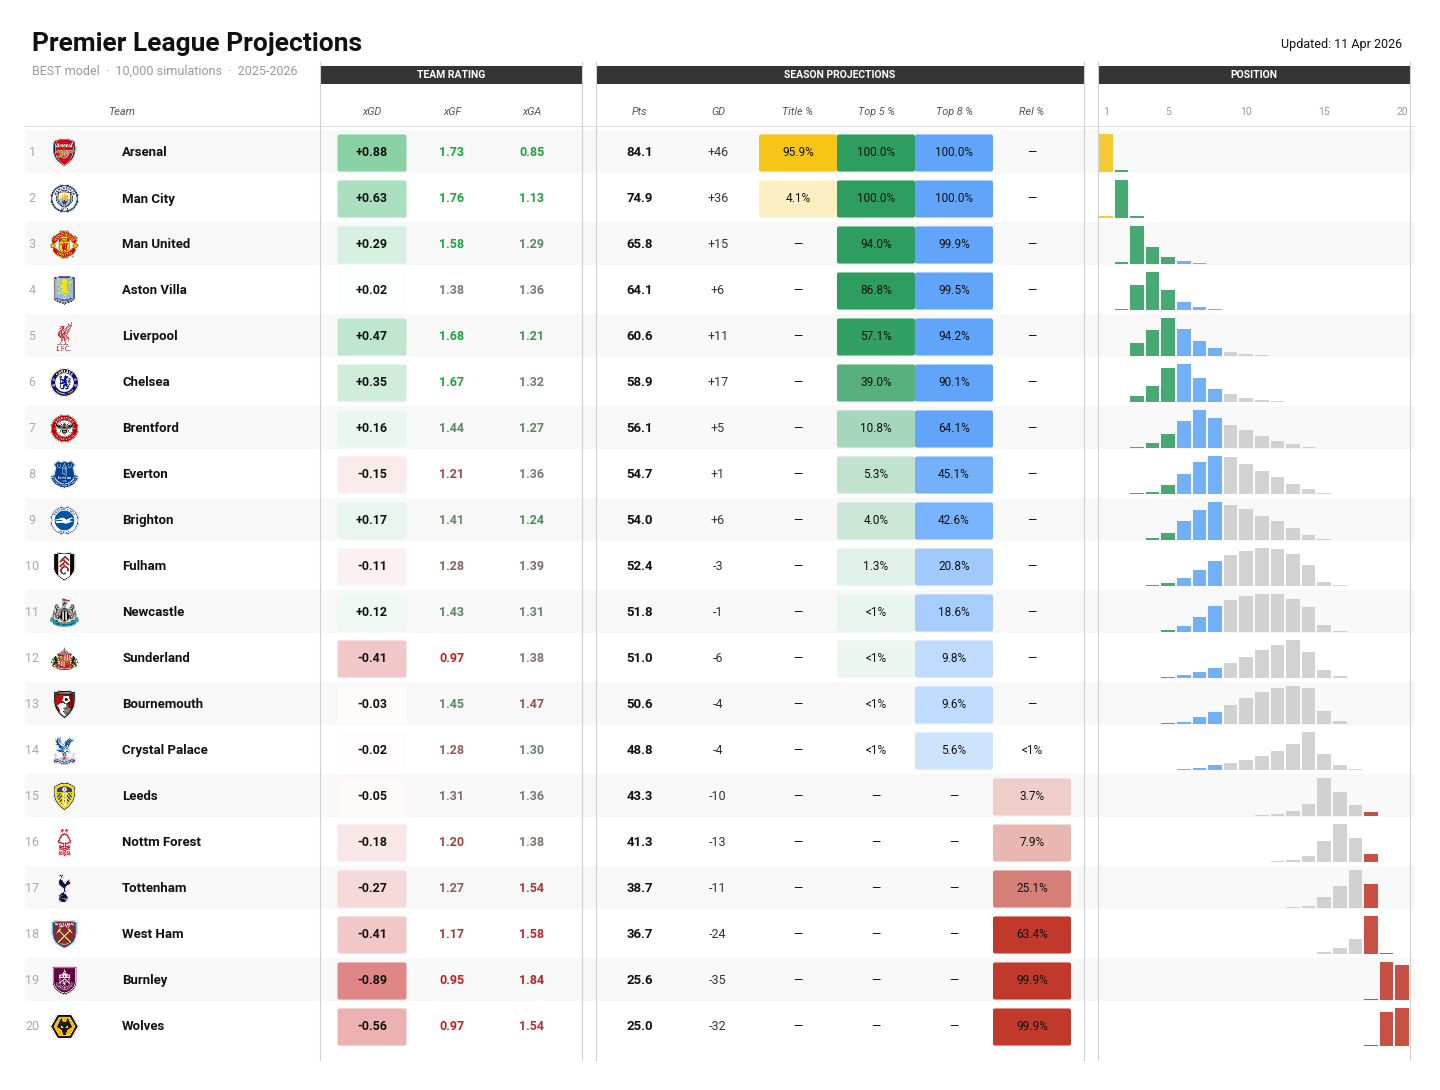

In [8]:
# ── 538-style combined table ──────────────────────────────────────────────────
fig = render_combined_table(
    avg_table     = avg_table,
    position_freq = position_freq,
    ratings_df    = ratings_df,
    n_sims        = N_SIMS,
    season        = SEASON,
    team_logos    = team_logos,
)
plt.savefig(os.path.join(str(NOTEBOOK_DIR), 'outputs', 'best_table.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Next 10 Fixture Predictions

In [9]:
# ── Fetch next 10 PL fixtures from TheSportsDB ───────────────────────────────
import requests
from scipy.stats import poisson

_SPORTSDB_TO_MODEL = {
    'Arsenal': 'Arsenal',
    'Aston Villa': 'Aston Villa',
    'Bournemouth': 'Bournemouth',
    'Brentford': 'Brentford',
    'Brighton and Hove Albion': 'Brighton',
    'Burnley': 'Burnley',
    'Chelsea': 'Chelsea',
    'Crystal Palace': 'Crystal Palace',
    'Everton': 'Everton',
    'Fulham': 'Fulham',
    'Leeds United': 'Leeds',
    'Liverpool': 'Liverpool',
    'Manchester City': 'Man City',
    'Manchester United': 'Man United',
    'Newcastle United': 'Newcastle',
    'Nottingham Forest': 'Nottm Forest',
    'Sunderland': 'Sunderland',
    'Tottenham Hotspur': 'Tottenham',
    'West Ham United': 'West Ham',
    'Wolverhampton Wanderers': 'Wolves',
}

def _get_upcoming_pl_fixtures(n=10, start_round=30):
    """Return next n unplayed PL fixtures."""
    fixtures = []
    for rnd in range(start_round, 39):
        try:
            r = requests.get(
                f'https://www.thesportsdb.com/api/v1/json/3/eventsround.php?id=4328&r={rnd}&s=2025-2026',
                timeout=10,
            )
            events = r.json().get('events') or []
        except Exception:
            continue
        for e in events:
            if e.get('intHomeScore') is None:
                fixtures.append({
                    'date':  e['dateEvent'],
                    'time':  (e.get('strTime') or '')[:5],
                    'gw':    e['intRound'],
                    'home':  _SPORTSDB_TO_MODEL.get(e['strHomeTeam'], e['strHomeTeam']),
                    'away':  _SPORTSDB_TO_MODEL.get(e['strAwayTeam'], e['strAwayTeam']),
                })
        if len(fixtures) >= n:
            break
    return fixtures[:n]

# ── Draw posterior samples once ───────────────────────────────────────────────
posterior = trace.posterior
_att  = posterior['att_str'].values.reshape(-1, n_teams)
_defn = posterior['def_str'].values.reshape(-1, n_teams)
_hadv = posterior['home_adv'].values.reshape(-1)
_base = posterior['baseline'].values.reshape(-1)
_rng  = np.random.choice(len(_base), size=2000, replace=True)

def _predict(home_team, away_team):
    """Return (home_lam, away_lam) including penalty baseline."""
    hi = team_mapping[home_team]
    ai = team_mapping[away_team]
    home_lam = np.mean(np.exp(
        _base[_rng] + _hadv[_rng] + _att[_rng, hi] + _defn[_rng, ai]
    )) + BASELINE_HOME_PENS
    away_lam = np.mean(np.exp(
        _base[_rng] + _att[_rng, ai] + _defn[_rng, hi]
    )) + BASELINE_AWAY_PENS
    return home_lam, away_lam

def _match_probs(home_lam, away_lam, max_goals=10):
    """Win / Draw / Loss probabilities via Poisson convolution."""
    h = np.array([poisson.pmf(g, home_lam) for g in range(max_goals + 1)])
    a = np.array([poisson.pmf(g, away_lam) for g in range(max_goals + 1)])
    grid = np.outer(h, a)
    win  = float(np.tril(grid, -1).sum())
    draw = float(np.trace(grid))
    loss = float(np.triu(grid,  1).sum())
    return win, draw, loss

# ── Build predictions ─────────────────────────────────────────────────────────
fixtures = _get_upcoming_pl_fixtures(11)
print(f"Fetched {len(fixtures)} fixtures")
rows = []
for f in fixtures:
    if f['home'] not in team_mapping or f['away'] not in team_mapping:
        print(f"Warning: unknown team(s) — {f['home']} / {f['away']}")
        continue
    hl, al = _predict(f['home'], f['away'])
    w, d, l = _match_probs(hl, al)
    rows.append({
        'GW':      f['gw'],
        'Date':    f['date'],
        'Time':    f['time'],
        'Home':    f['home'],
        'Away':    f['away'],
        'Home xG': round(hl, 2),
        'Away xG': round(al, 2),
        'Home W%': round(w * 100, 1),
        'Draw%':   round(d * 100, 1),
        'Away W%': round(l * 100, 1),
    })

pred_df = pd.DataFrame(rows)
pred_df


Fetched 11 fixtures


,GW,Date,Time,Home,Away,Home xG,Away xG,Home W%,Draw%,Away W%
0,31,2026-03-21,15:00,Man City,Crystal Palace,1.80,0.98,56.6,23.0,20.4
1,32,2026-04-11,11:30,Arsenal,Bournemouth,2.01,0.84,64.7,20.5,14.8
2,32,2026-04-11,14:00,Brentford,Everton,1.54,1.05,48.6,25.5,25.9
3,32,2026-04-11,14:00,Burnley,Brighton,0.96,1.74,20.7,23.6,55.6
4,32,2026-04-11,16:30,Liverpool,Fulham,1.85,1.05,55.9,22.7,21.4
5,32,2026-04-12,15:30,Chelsea,Man City,1.53,1.59,36.9,23.7,39.4
6,32,2026-04-12,13:00,Crystal Palace,Newcastle,1.35,1.25,39.2,26.4,34.5
7,32,2026-04-12,13:00,Nottm Forest,Aston Villa,1.29,1.28,36.9,26.6,36.5
8,32,2026-04-12,13:00,Sunderland,Tottenham,1.18,1.18,36.0,28.0,36.0
9,32,2026-04-13,19:00,Man United,Leeds,1.71,1.16,50.4,23.9,25.7


## Power rankings — short window + season simulation

In [10]:
# ── Power rankings — short window form ratings ───────────────────────────────
WINDOW_START = '2025-12-01'

pr_df, pr_map, pr_n = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON, start=WINDOW_START,
    decay_rate=0.025, goals_weight=GOALS_WEIGHT,
    xg_weight=XG_WEIGHT, psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
print(f'Window: {WINDOW_START} → latest  |  {pr_n} teams, {pr_df["match_id"].nunique()} matches')

pr_form = form_net_rating(pr_df)
pr_form['rank'] = range(1, len(pr_form) + 1)
pr_form

Window: 2025-12-01 → latest  |  20 teams, 179 matches


,gf_avg,ga_avg,net_rating,rank
home_team,,,,
Arsenal,1.722618,0.861872,0.860746,1
Man City,1.720340,1.054569,0.665771,2
Man United,1.477207,1.074544,0.402663,3
Brighton,1.362571,0.994388,0.368183,4
Liverpool,1.615316,1.321212,0.294104,5
Chelsea,1.599368,1.343410,0.255958,6
Brentford,1.440024,1.219457,0.220567,7
Bournemouth,1.412561,1.271162,0.141399,8
Fulham,1.408252,1.268902,0.139350,9


In [11]:
# Top 10 form teams
pr_form[['net_rating', 'rank']].head(10)

,net_rating,rank
home_team,,
Arsenal,0.860746,1
Man City,0.665771,2
Man United,0.402663,3
Brighton,0.368183,4
Liverpool,0.294104,5
Chelsea,0.255958,6
Brentford,0.220567,7
Bournemouth,0.141399,8
Fulham,0.139350,9


## HTML Power Rankings Export

Generates `substack_power_rankings.html`. Open in browser → Select All (Cmd+A) → Copy → Paste into Substack.

In [12]:
# ── Form ratings: current window vs previous week ─────────────────────────────
df_form_current, _, _ = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON,
    start=FORM_START, end=FORM_END,
    decay_rate=0.025,
    goals_weight=GOALS_WEIGHT, xg_weight=XG_WEIGHT,
    psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
form_current = form_net_rating(df_form_current)
form_current['form_rank'] = range(1, len(form_current) + 1)

df_form_prev, _, _ = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON,
    start=FORM_START, end=FORM_PREV_END,
    decay_rate=0.025,
    goals_weight=GOALS_WEIGHT, xg_weight=XG_WEIGHT,
    psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
form_prev = form_net_rating(df_form_prev)
form_prev['prev_form_rank'] = range(1, len(form_prev) + 1)

form_merged = form_current.merge(
    form_prev[['prev_form_rank']], left_index=True, right_index=True, how='left'
)
print(form_merged[['net_rating', 'form_rank', 'prev_form_rank']].head(10))

# ── Actual standings ──────────────────────────────────────────────────────────
played = df_actual[df_actual['home_goals'].notna()].copy()
_teams = list(team_mapping.keys())
pts_d = {t: 0 for t in _teams}
gf_d  = {t: 0 for t in _teams}
ga_d  = {t: 0 for t in _teams}
for _, r in played.iterrows():
    h, a = r['home_team'], r['away_team']
    if h not in pts_d or a not in pts_d:
        continue
    hg, ag = int(r['home_goals']), int(r['away_goals'])
    gf_d[h] += hg; ga_d[h] += ag
    gf_d[a] += ag; ga_d[a] += hg
    if   hg > ag: pts_d[h] += 3
    elif ag > hg: pts_d[a] += 3
    else:         pts_d[h] += 1; pts_d[a] += 1

standings = pd.DataFrame({
    'team': _teams,
    'pts':  [pts_d[t] for t in _teams],
    'gf':   [gf_d[t]  for t in _teams],
    'ga':   [ga_d[t]  for t in _teams],
    'gd':   [gf_d[t] - ga_d[t] for t in _teams],
}).sort_values(['pts', 'gd', 'gf'], ascending=False).reset_index(drop=True)
standings['table_pos'] = range(1, len(standings) + 1)

# ── Ratings ranks ─────────────────────────────────────────────────────────────
ratings_ranked = ratings_df.copy()
ratings_ranked['att_rank'] = ratings_ranked['goals_for'].rank(ascending=False).astype(int)
ratings_ranked['def_rank'] = ratings_ranked['goals_against'].rank(ascending=True).astype(int)
print(standings[['team', 'pts', 'gd', 'table_pos']].to_string(index=False))

             net_rating  form_rank  prev_form_rank
home_team                                         
Arsenal        0.854327          1               1
Man City       0.672549          2               2
Man United     0.409567          3               3
Brighton       0.376412          4               4
Liverpool      0.303965          5               5
Chelsea        0.250298          6               6
Brentford      0.237028          7               7
Bournemouth    0.148051          8               8
Fulham         0.138372          9               9
Leeds         -0.020945         10              10
          team  pts  gd  table_pos
       Arsenal   70  39          1
      Man City   61  32          2
    Man United   55  13          3
   Aston Villa   54   5          4
     Liverpool   49   8          5
       Chelsea   48  15          6
     Brentford   46   4          7
       Everton   46   2          8
        Fulham   44  -1          9
      Brighton   43   4         10
   

In [13]:
# ── Generate Substack HTML ────────────────────────────────────────────────────
output_html = os.path.join(str(NOTEBOOK_DIR), 'outputs', 'substack_power_rankings.html')
render_html_export(
    form_merged    = form_merged,
    standings      = standings,
    ratings_ranked = ratings_ranked,
    team_logos     = team_logos,
    df_actual      = df_actual,
    form_end       = FORM_END,
    output_path    = output_html,
    get_last_result = get_last_result,
    get_form_string = get_form_string,
    rank_arrow      = rank_arrow,
)

Saved to /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league/outputs/substack_power_rankings.html
Open in a browser → Select All (Cmd+A) → Copy (Cmd+C) → Paste into Substack.


'/Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league/outputs/substack_power_rankings.html'

## Ratings evolution — GW5 onwards

Fits the model after each gameweek and tracks how team strengths change across the season.

**Runtime note:** at 20k/10k draws this loop takes a while (~15 min per GW).
Lower `N_SAMPLES_EVOLUTION` in the setup cell if you want it faster.

In [14]:
# Identify gameweek cutoff dates — each GW = 10 matches (robust to festive fixture congestion)
match_df_evo, *_ = load_football_data(DB_PATH, LEAGUE, SEASON)
played_evo = match_df_evo[match_df_evo['home_goals'].notna()].copy()
played_evo['match_date'] = pd.to_datetime(played_evo['match_date'])
played_evo = played_evo.sort_values("match_date").reset_index(drop=True)

MATCHES_PER_GW = 10
gw_cutoffs = []
for start in range(0, len(played_evo), MATCHES_PER_GW):
    chunk = played_evo.iloc[start:start + MATCHES_PER_GW]
    gw_cutoffs.append(chunk['match_date'].max().date())

print(f"{len(gw_cutoffs)} gameweeks detected")
print(f"GW1 end: {gw_cutoffs[0]}   GW5 end: {gw_cutoffs[4]}   Last GW: {gw_cutoffs[-1]}")


31 gameweeks detected
GW1 end: 2025-08-18   GW5 end: 2025-09-21   Last GW: 2026-03-22


In [15]:
# Consistent team index across all GW iterations
all_teams = sorted(set(played_evo['home_team'].unique()) | set(played_evo['away_team'].unique()))
full_map  = {t: i for i, t in enumerate(all_teams)}
n_all     = len(all_teams)

from manual_priors import MANUAL_ATT_PRIORS, MANUAL_DEF_PRIORS

def fit_gw(cutoff_date):
    """Fit the same model as the main run, on data up to cutoff_date."""
    gw_df, _, _ = load_and_process_data(
        db_path=DB_PATH, league=LEAGUE, season=SEASON,
        end=cutoff_date,
        decay_rate=DECAY_RATE, goals_weight=GOALS_WEIGHT,
        xg_weight=XG_WEIGHT, psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
    )
    # Override indices to use the full consistent team list
    gw_df = gw_df.copy()
    gw_df['home_idx'] = gw_df['home_team'].map(full_map).astype(int)
    gw_df['away_idx'] = gw_df['away_team'].map(full_map).astype(int)

    _, tr = build_and_sample_model(
        gw_df, n_all,
        trace=N_SAMPLES_EVOLUTION, tune=N_TUNE_EVOLUTION,
        team_mapping=full_map,
        manual_att_priors=MANUAL_ATT_PRIORS,
        manual_def_priors=MANUAL_DEF_PRIORS,
    )
    post = tr.posterior
    return (
        post['att_str'].values.reshape(-1, n_all).mean(axis=0),
        post['def_str'].values.reshape(-1, n_all).mean(axis=0),
    )

# Run from GW5 onwards (index 4)
evo_records = []
for gw_num, cutoff in enumerate(gw_cutoffs[4:], start=5):
    print(f'GW{gw_num} ({cutoff})...', end=' ', flush=True)
    att_means, def_means = fit_gw(cutoff)
    for i, team in enumerate(all_teams):
        evo_records.append({
            'gw':      gw_num,
            'date':    cutoff,
            'team':    team,
            'att':     att_means[i],
            'def':     def_means[i],
            'net':     att_means[i] - def_means[i],
        })
    print('done')

evo_df = pd.DataFrame(evo_records)
print(f'Evolution data: {len(evo_df)} rows')

GW5 (2025-09-21)... done
GW6 (2025-09-29)... done
GW7 (2025-10-05)... done
GW8 (2025-10-20)... done
GW9 (2025-10-26)... done
GW10 (2025-11-03)... done
GW11 (2025-11-09)... done
GW12 (2025-11-24)... done
GW13 (2025-11-30)... done
GW14 (2025-12-04)... done
GW15 (2025-12-08)... done
GW16 (2025-12-15)... done
GW17 (2025-12-22)... done
GW18 (2025-12-28)... done
GW19 (2026-01-01)... 

In [ ]:
for metric in ['net', 'att', 'def']:
    fig = render_evo_chart(evo_df, metric=metric, season=SEASON, league='Premier League',
        save_path=os.path.join(str(NOTEBOOK_DIR), 'outputs', f'evo_{metric}.png'))
    plt.show()